# Validación psicométrica de los embedding


Sobre la matriz de embeddings de la rama visual (n × 256) del GeoVision-CLIP se aplica Análisis Factorial Exploratorio con
extracción por Componentes Principales y rotación Varimax. Se determina el número de factores $m$  a
retener vía Scree Plot y varianza acumulada (criterio: m que explique ≥ 80%). Posteriormente, se especifica
un modelo de medición confirmatorio con cuatro constructos latentes hipotetizados — Carga
Antropogénica, Estrés Vegetal, Densidad Urbana, Volatilidad Atmosférica — y evalua la bondad de ajuste
con RMSEA, CFI y SRMR, para concluir sobre la validez de constructo.

## Import y Configs

In [1]:
%pip install factor_analyzer kneed semopy -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from kneed import KneeLocator
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from factor_analyzer import FactorAnalyzer, Rotator
from factor_analyzer.confirmatory_factor_analyzer import (
    ConfirmatoryFactorAnalyzer,
    ModelSpecification,
)
from factor_analyzer.factor_analyzer import (
    calculate_bartlett_sphericity,
    calculate_kmo,
)

from plotly.subplots import make_subplots
import semopy

FIGURAS_DIR = "/teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2"
os.makedirs(FIGURAS_DIR, exist_ok=True)
print(f"[OK] Directorio de figuras: {FIGURAS_DIR}")

[OK] Directorio de figuras: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2


# Carga de Embeddings

In [3]:
# ============================================================================
# 1. CARGA DE EMBEDDINGS (reemplazar con la ruta real)
# ============================================================================
def load_embeddings(data_path=None, n_samples=2000, n_features=512, synthetic=False):
    """
    Carga los embeddings reales o genera datos sintéticos para prueba.
    
    Parámetros:
        data_path: str, ruta al archivo .npy o .csv (si synthetic=False)
        n_samples: int, número de muestras (solo para sintéticos)
        n_features: int, número de características (512 en el proyecto)
        synthetic: bool, si True genera datos con estructura factorial conocida
    
    Retorna:
        X: np.ndarray de shape (n_samples, n_features)
    """
    if synthetic:
        print("[INFO] Generando datos sintéticos con 4 factores latentes (solo demostración).")
        np.random.seed(42)
        # Crear factores latentes (4 factores)
        n_factors = 4
        # Matriz de cargas: cada característica se asocia a un factor dominante
        loadings_true = np.zeros((n_features, n_factors))
        block_size = n_features // n_factors
        for i in range(n_factors):
            start = i * block_size
            end = (i + 1) * block_size if i < n_factors-1 else n_features
            loadings_true[start:end, i] = np.random.uniform(0.5, 0.9, end-start)
        # Añadir cargas cruzadas pequeñas
        loadings_true += np.random.normal(0, 0.1, (n_features, n_factors))
        # Factores latentes (normalizados)
        factors = np.random.normal(0, 1, (n_samples, n_factors))
        # Ruido
        noise = np.random.normal(0, 0.5, (n_samples, n_features))
        X = factors @ loadings_true.T + noise
        # Estandarizar
        X = StandardScaler().fit_transform(X)
        return X
    else:
        if data_path is None:
            raise ValueError("Debe proporcionar data_path para embeddings reales o usar synthetic=True.")
        if data_path.endswith('.npy'):
            X = np.load(data_path)
        elif data_path.endswith('.csv'):
            X = pd.read_csv(data_path).values
        else:
            raise ValueError("Formato no soportado. Use .npy o .csv")
        print(f"[OK] Embeddings cargados: {X.shape}")
        return X

# Pruebas de Adecuación (KMO y Barlett)

In [4]:

# ============================================================================
# 2. PRUEBAS DE ADECUACIÓN (KMO y Bartlett)
# ============================================================================
def test_adequacy(X):
    print("\n" + "="*70)
    print("PRUEBAS DE ADECUACIÓN PARA ANÁLISIS FACTORIAL")
    print("="*70)

    # KMO — en datos SAE de alta dimensión la matriz de correlación es casi singular.
    # Fallback: calcular KMO sobre los primeros 100 componentes PCA.
    import warnings
    kmo_model = np.nan
    kmo_note  = ""
    for X_kmo, label in [(X, f"{X.shape[1]} dims"), (None, "PCA-100")]:
        if label == "PCA-100":
            n_pca = min(100, X.shape[0] - 1, X.shape[1])
            X_kmo = PCA(n_components=n_pca).fit_transform(X)
            kmo_note = (f" (matriz singular en {X.shape[1]} dims — "
                        f"KMO calculado sobre {n_pca} componentes PCA)")
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                _, kmo_model = calculate_kmo(pd.DataFrame(X_kmo))
            if not np.isnan(kmo_model):
                break
        except Exception:
            pass

    print(f"\nKMO global (MSA): {kmo_model:.4f}{kmo_note}")
    if np.isnan(kmo_model):
        print("  → No calculable (singularidad numérica irreducible)")
    elif kmo_model >= 0.9:
        print("  → Excelente")
    elif kmo_model >= 0.8:
        print("  → Meritorio")
    elif kmo_model >= 0.7:
        print("  → Mediano")
    elif kmo_model >= 0.6:
        print("  → Mediocre")
    else:
        print("  → Inaceptable (no proceder con AF)")

    # Bartlett
    chi2, p = calculate_bartlett_sphericity(pd.DataFrame(X))
    print(f"\nPrueba de esfericidad de Bartlett:")
    if np.isinf(chi2):
        print(f"  Chi-cuadrado = ∞  (|R|≈0 con {X.shape[1]} dims — desbordamiento numérico esperado en datos SAE de alta dimensión)")
    else:
        print(f"  Chi-cuadrado = {chi2:.4f}")
    print(f"  p-valor = {p:.6e}")
    if p < 0.05:
        print("  → Significativo: las variables están correlacionadas, AF procede.")
    else:
        print("  → No significativo: AF no recomendado.")

    return kmo_model, p

# Determinación del Número de Factores

In [5]:
# ============================================================================
# 3. DETERMINACIÓN DEL NÚMERO DE FACTORES
# ============================================================================
def determine_n_factors(X, max_factors=20, var_threshold=0.80):
    print("\n" + "="*70)
    print("DETERMINACIÓN DEL NÚMERO DE FACTORES")
    print("="*70)

    n_comp = min(X.shape[0] - 1, X.shape[1])
    pca_full = PCA(n_components=n_comp)
    pca_full.fit(X)

    ev_all    = pca_full.explained_variance_
    cv_all    = np.cumsum(pca_full.explained_variance_ratio_)
    ev        = ev_all[:max_factors]
    cum_var   = cv_all[:max_factors]
    var_ratio = pca_full.explained_variance_ratio_[:max_factors]

    x_vals = list(range(1, len(ev) + 1))
    kn     = KneeLocator(x_vals, ev.tolist(), curve='convex', direction='decreasing')
    elbow  = kn.elbow if kn.elbow is not None else 2

    n_kaiser  = int(np.sum(ev_all > 1))
    n_by_var  = int(np.argmax(cv_all >= var_threshold)) + 1

    n_sim  = 100
    ev_sim = []
    rng    = np.random.default_rng(42)
    for _ in range(n_sim):
        X_perm = X.copy()
        for j in range(X.shape[1]):
            X_perm[:, j] = rng.permutation(X[:, j])
        pca_sim = PCA(n_components=max_factors)
        pca_sim.fit(X_perm)
        ev_sim.append(pca_sim.explained_variance_)
    ev_sim_95  = np.percentile(ev_sim, 95, axis=0)
    n_parallel = int(np.sum(ev[:len(ev_sim_95)] > ev_sim_95[:len(ev)]))

    print(f"\nCriterio de Kaiser (eigenvalor > 1):          {n_kaiser} factores")
    print(f"Codo en Scree plot (KneeLocator):              {elbow} factores")
    print(f"Varianza acumulada >= {var_threshold*100:.0f}%:               {n_by_var} factores")
    print(f"Análisis paralelo (Horn, p95):                 {n_parallel} factores")

    # Criterio del proyecto (PDF Sit.2): m que explique ≥ 80% varianza acumulada.
    # Se toma el mayor entre ese umbral y el análisis paralelo para no subestimar.
    suggested = max(n_by_var, n_parallel)
    print(f"\n>> Número de factores sugerido: {suggested} "
          f"(max de varianza-acumulada={n_by_var} y paralelo={n_parallel})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Panel izquierdo: Scree Plot ──────────────────────────────────────────
    axes[0].plot(x_vals, ev, 'bo-', markersize=6, label='Eigenvalores reales')
    axes[0].plot(x_vals[:len(ev_sim_95)], ev_sim_95, 'r--', alpha=0.8, label='Paralelo p95')
    axes[0].axhline(y=1, color='gray', linestyle=':', label='Kaiser (λ=1)')
    axes[0].axvline(x=elbow, color='g', linestyle='--', label=f'Codo ≈ {elbow}')
    axes[0].axvline(x=suggested, color='darkgreen', linestyle='-.',
                    linewidth=1.5, label=f'Sugeridos: {suggested}')
    ev_suggested = float(ev[min(suggested - 1, len(ev) - 1)])
    axes[0].annotate(
        f"Factor {suggested} retenido",
        xy=(suggested, ev_suggested),
        xytext=(min(suggested + 1.5, max_factors - 1), ev_suggested + max(ev) * 0.08),
        arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5),
        fontsize=9, color='darkgreen', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='honeydew', ec='darkgreen', alpha=0.85)
    )
    axes[0].set_title('Scree Plot con Análisis Paralelo (Horn)')
    axes[0].set_xlabel('Número de factor')
    axes[0].set_ylabel('Eigenvalor')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    # ── Panel derecho: Varianza acumulada ────────────────────────────────────
    axes[1].bar(x_vals, var_ratio, alpha=0.6, label='Var. individual')
    axes[1].plot(x_vals, cum_var, 'ro-', markersize=5, label='Var. acumulada')
    axes[1].axhline(y=var_threshold, color='orange', linestyle='--',
                    label=f'{var_threshold*100:.0f}% umbral KPI')
    axes[1].axvline(x=n_by_var, color='purple', linestyle='--', label=f'n={n_by_var}')
    ann_y = float(cum_var[min(n_by_var - 1, len(cum_var) - 1)])
    ann_x_text = min(n_by_var + 1.5, max_factors - 1)
    ann_y_text = max(ann_y - 0.14, 0.15)
    axes[1].annotate(
        f"Factor {n_by_var} → {ann_y * 100:.2f}%\nvarianza acumulada",
        xy=(n_by_var, ann_y),
        xytext=(ann_x_text, ann_y_text),
        arrowprops=dict(arrowstyle='->', color='purple', lw=1.5),
        fontsize=9, color='purple', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='lavender', ec='purple', alpha=0.85)
    )
    axes[1].set_title('Varianza explicada acumulada')
    axes[1].set_xlabel('Número de factor')
    axes[1].set_ylabel('Proporción de varianza')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{FIGURAS_DIR}/scree_plot_varianza.png", dpi=150)
    plt.show()
    print(f"[OK] Figura guardada: {FIGURAS_DIR}/scree_plot_varianza.png")

    return suggested, n_by_var

# Análisis Factorial Exploratorio (AFE)

In [6]:
# ============================================================================
# 4. ANÁLISIS FACTORIAL EXPLORATORIO (EFA)
# ============================================================================
def efa_analysis(X, n_factors):
    """
    Extracción PCA + rotación Varimax (método solicitado en el proyecto).
    Fallback a quartimax → sin rotación si el SVD no converge (datos esparsos).
    """
    print("\n" + "="*70)
    print(f"ANÁLISIS FACTORIAL EXPLORATORIO ({n_factors} factores, rotación Varimax)")
    print("="*70)

    pca = PCA(n_components=n_factors)
    pca.fit(X)
    loadings_unrot = pca.components_.T * np.sqrt(pca.explained_variance_)

    # Rotación Varimax con fallbacks ante SVD no convergente (datos muy esparsos)
    rotation_used = 'varimax'
    loadings_rot  = None
    for method in ('varimax', 'quartimax', None):
        if method is None:
            print("[ADVERTENCIA] Varimax y quartimax fallaron — usando cargas PCA sin rotar.")
            loadings_rot  = loadings_unrot.copy()
            rotation_used = 'none (PCA)'
            break
        try:
            loadings_rot  = Rotator(method=method).fit_transform(loadings_unrot)
            rotation_used = method
            if method != 'varimax':
                print(f"[INFO] Varimax no convergió — rotación usada: {method}")
            break
        except np.linalg.LinAlgError:
            print(f"[ADVERTENCIA] SVD no convergió con '{method}' — probando siguiente.")

    print(f"Rotación aplicada: {rotation_used}")

    var_real = (loadings_rot ** 2).sum() / X.shape[1] * 100
    print(f"Varianza total explicada (Varimax, {n_factors} factores): {var_real:.2f}%")

    factor_names = [f'Factor{i+1}' for i in range(n_factors)]
    loadings_df = pd.DataFrame(
        loadings_rot,
        index=range(X.shape[1]),
        columns=factor_names
    )

    print("\nMatriz de cargas rotadas (primeras 20 dims):")
    print(loadings_df.head(20).round(3).to_string())

    communalities = (loadings_rot ** 2).sum(axis=1)
    comm_df = pd.DataFrame({
        'Variable'    : [f'Dim_{i}' for i in range(X.shape[1])],
        'Comunalidad' : communalities
    }).sort_values('Comunalidad', ascending=False)
    print(f"\nComunalidades (h²) — top 10 (media={communalities.mean():.4f}):")
    print(comm_df.head(10).to_string(index=False))

    ss_loadings = (loadings_rot ** 2).sum(axis=0)
    var_pct     = ss_loadings / X.shape[1] * 100
    var_cum     = np.cumsum(var_pct)
    var_df = pd.DataFrame(
        [ss_loadings, var_pct, var_cum],
        index=['SS Loadings', '% Varianza', '% Acumulado'],
        columns=factor_names
    )
    print("\nVarianza explicada por factor (rotación Varimax):")
    print(var_df.round(3).to_string())

    total_var = ss_loadings.sum() / X.shape[1] * 100
    kpi_ok  = total_var >= 80
    kpi_exc = total_var >= 90
    status  = 'EXCELENTE (>=90%)' if kpi_exc else ('CUMPLE (>=80%)' if kpi_ok else 'NO CUMPLE (<80%)')
    print(f"\nVarianza total explicada: {total_var:.2f}%  →  KPI: {status}")

    max_load   = loadings_df.abs().max(axis=1)
    assignment = loadings_df.abs().idxmax(axis=1)
    assignment[max_load < 0.30] = 'No asignado'
    print("\nDimensiones por factor dominante (|carga| > 0.30):")
    print(assignment.value_counts().to_string())

    n_show = min(64, X.shape[1])
    plt.figure(figsize=(max(8, n_factors * 2), 10))
    sns.heatmap(loadings_df.iloc[:n_show], annot=False,
                cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                linewidths=0.2, linecolor='lightgray')
    plt.title(f'Cargas factoriales {rotation_used} — {n_factors} factores (primeras {n_show} dims)')
    plt.xlabel('Factor')
    plt.ylabel('Dimensión embedding')
    plt.tight_layout()
    plt.savefig(f"{FIGURAS_DIR}/efa_loadings_heatmap.png", dpi=150)
    plt.show()
    print(f"[OK] Figura guardada: {FIGURAS_DIR}/efa_loadings_heatmap.png")

    return loadings_df, pca


# 5. Análisis Factorial Confirmatorio (AFC)


In [7]:
# ============================================================================
# 5. ANÁLISIS FACTORIAL CONFIRMATORIO (CFA)
# ============================================================================
def cfa_analysis(X, loadings_df_efa=None, items_per_factor=5, verbose=False):
    """
    CFA con los 4 constructos hipotéticos del proyecto (semopy).
    Umbral de carga ≥ 0.40 (estándar psicométrico).
    """
    print("\n" + "="*70)
    print("ANÁLISIS FACTORIAL CONFIRMATORIO (CFA) — Modelo de 4 factores")
    print("="*70)

    THEORETICAL = [
        'CargaAntropogenica',
        'EstresVegetal',
        'DensidadUrbana',
        'VolatilidadAtmosferica'
    ]

    pca4 = PCA(n_components=4)
    pca4.fit(X)
    lr4 = Rotator(method='varimax').fit_transform(
        pca4.components_.T * np.sqrt(pca4.explained_variance_)
    )
    ld4 = pd.DataFrame(lr4, index=range(X.shape[1]), columns=THEORETICAL)

    var4 = (lr4**2).sum() / X.shape[1] * 100
    print(f"\nVarianza explicada (4 factores Varimax): {var4:.2f}%")
    print("  Nota: el EFA exploratorio usa más factores para alcanzar el KPI 80%;")
    print("  el CFA testa la estructura teórica de 4 constructos por separado.\n")

    c_assign  = ld4.abs().idxmax(axis=1)
    c_maxload = ld4.abs().max(axis=1)

    factor_items_map = {}
    selected_idx = []

    for theo_f in THEORETICAL:
        # Umbral psicométrico estándar: |carga| ≥ 0.40
        mask = (c_assign == theo_f) & (c_maxload >= 0.40)
        candidates = ld4.index[mask].tolist()
        if len(candidates) < 3:
            candidates = ld4.index[c_assign == theo_f].tolist()
        if len(candidates) == 0:
            # Último fallback: top por carga absoluta en este factor
            candidates = ld4[theo_f].abs().nlargest(items_per_factor).index.tolist()
        top = sorted(candidates, key=lambda i: abs(ld4.loc[i, theo_f]), reverse=True)[:items_per_factor]
        factor_items_map[theo_f] = top
        selected_idx.extend(top)
        if top:
            print(f"  {theo_f}: dims {top}  (|carga máx|={ld4.loc[top[0], theo_f]:.3f})")
        else:
            print(f"  {theo_f}: sin ítems asignados (factor vacío)")

    seen, uniq_idx = set(), []
    for i in selected_idx:
        if i not in seen:
            seen.add(i); uniq_idx.append(i)

    model_str = ""
    for theo_f, items in factor_items_map.items():
        vnames = [f'v{idx}' for idx in items]
        if len(vnames) >= 3:
            model_str += f"{theo_f} =~ {' + '.join(vnames)}\n"
    print("\nModelo CFA:\n" + model_str)

    df_cfa = pd.DataFrame(X[:, uniq_idx], columns=[f'v{i}' for i in uniq_idx])
    print(f"Variables observadas: {df_cfa.shape[1]} | Muestras: {df_cfa.shape[0]}")

    # Invertir ítems anticorrelacionados en EstresVegetal
    for col in ['v496', 'v111', 'v503', 'v359']:
        if col in df_cfa.columns:
            df_cfa[col] = df_cfa[col] * -1

    try:
        model = semopy.Model(model_str)
        model.fit(df_cfa)

        fit_stats = semopy.calc_stats(model)
        print("\n=== ÍNDICES DE BONDAD DE AJUSTE ===")
        print(fit_stats.T.to_string())

        # Extraer RMSEA y CFI: construir dict normalizado manejando NaN explícitamente
        _ft  = fit_stats.T   # index=stats, columns=['Value']
        _col = 'Value' if 'Value' in _ft.columns else _ft.columns[0]
        _raw = {}
        for _k in _ft.index:
            try:
                _raw[str(_k).strip().upper()] = _ft.at[_k, _col]
            except Exception:
                pass

        def _parse(key):
            v = _raw.get(key)
            if v is None:
                return None
            try:
                f = float(v)
                return None if (f != f) else f   # NaN check: NaN != NaN
            except (ValueError, TypeError):
                return None

        rmsea = _parse('RMSEA')
        cfi   = _parse('CFI')

        # Fallback: calcular RMSEA manualmente si semopy lo devuelve como NaN
        if rmsea is None:
            chi2_v = _parse('CHI2') or _parse('CHI2 VALUE')
            dof_v  = _parse('DOF') or _parse('DF')
            n_obs  = df_cfa.shape[0]
            if chi2_v and dof_v and dof_v > 0:
                rmsea = float(np.sqrt(max(0.0, (chi2_v / dof_v - 1.0) / (n_obs - 1.0))))
                print(f"[INFO] RMSEA calculado: chi2={chi2_v:.2f}, df={dof_v:.0f}, n={n_obs}")

        # ── SRMR: cálculo robusto con manejo de errores explícito ────────────
        srmr     = None
        srmr_err = None
        try:
            # Intentar calc_sigma() (semopy >= 2.x)
            sigma_result = model.calc_sigma()
            sigma_hat    = sigma_result[0] if isinstance(sigma_result, tuple) else sigma_result
        except AttributeError:
            # Fallback: atributo directo
            sigma_hat = getattr(model, 'mx_sigma', None)
            if sigma_hat is None:
                srmr_err = "modelo no expone calc_sigma() ni mx_sigma"

        if sigma_hat is not None:
            obs_cov = df_cfa.cov().values
            if sigma_hat.shape == obs_cov.shape:
                sds       = np.sqrt(np.maximum(np.diag(obs_cov), 1e-12))
                outer_sds = np.outer(sds, sds)
                resid_std = (obs_cov - sigma_hat) / outer_sds
                tril_idx  = np.tril_indices(obs_cov.shape[0], k=0)
                srmr      = float(np.sqrt(np.mean(resid_std[tril_idx] ** 2)))
            else:
                srmr_err = (f"Shape mismatch: sigma_hat={sigma_hat.shape}, "
                            f"obs_cov={obs_cov.shape}")
        elif srmr_err is None:
            srmr_err = "sigma_hat es None tras intentar calc_sigma()"

        print("\n=== KPIs DEL PROYECTO ===")
        if rmsea is not None:
            s = 'EXCELENTE' if rmsea < 0.05 else ('CUMPLE' if rmsea < 0.08 else 'NO CUMPLE')
            print(f"  RMSEA = {rmsea:.4f}  (< 0.08 mín, < 0.05 excel) → {s}")
        else:
            print("  RMSEA = N/A  (no reportado por semopy)")

        if cfi is not None:
            s = 'EXCELENTE' if cfi > 0.95 else ('CUMPLE' if cfi > 0.90 else 'NO CUMPLE')
            print(f"  CFI   = {cfi:.4f}  (> 0.90 mín, > 0.95 excel) → {s}")
        else:
            print("  CFI   = N/A  (no reportado por semopy)")

        if srmr is not None:
            s = 'CUMPLE' if srmr < 0.08 else 'NO CUMPLE'
            print(f"  SRMR  = {srmr:.4f}  (< 0.08) → {s}")
        else:
            print(f"  SRMR  = N/A  ({srmr_err})")

        # ── Cargas factoriales — compatible con distintas versiones de semopy ──
        params     = model.inspect()
        if verbose:
            print(f"\n[verbose] Columnas inspect(): {params.columns.tolist()}")
            print(f"[verbose] Operadores únicos:   {params['op'].unique().tolist()}")

        mask_load = params['op'].isin(['=~', '~'])
        mask_theo = params['lval'].isin(THEORETICAL) | params['rval'].isin(THEORETICAL)
        est = params[mask_load & mask_theo][['lval', 'op', 'rval', 'Estimate']].copy()
        if est.empty:
            est = params[mask_load][['lval', 'op', 'rval', 'Estimate']].copy()

        print("\nCargas factoriales CFA estimadas:")
        if not est.empty:
            print(est.to_string(index=False))

            # Gráfico de barras de cargas por constructo
            fig_bar, axes_bar = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
            for ax, theo_f in zip(axes_bar, THEORETICAL):
                mask_f = est['lval'].str.contains(theo_f) | est['rval'].str.contains(theo_f)
                sub    = est[mask_f].copy()
                if sub.empty:
                    ax.set_title(theo_f); continue
                labels = sub.apply(
                    lambda r: r['rval'] if r['lval'] == theo_f else r['lval'], axis=1
                )
                vals   = sub['Estimate'].values
                colors = ['steelblue' if v >= 0 else 'tomato' for v in vals]
                ax.barh(labels, vals, color=colors)
                ax.axvline(0, color='black', linewidth=0.8)
                ax.set_title(theo_f, fontsize=9)
                ax.set_xlabel('Carga estimada')
            plt.suptitle('Cargas factoriales CFA (semopy) — 4 constructos', y=1.02)
            plt.tight_layout()
            plt.savefig(f"{FIGURAS_DIR}/cfa_loadings_barplot.png", dpi=150,
                        bbox_inches='tight')
            plt.show()
            print(f"[OK] Figura guardada: {FIGURAS_DIR}/cfa_loadings_barplot.png")
        else:
            print("  [ADVERTENCIA] No se encontraron cargas factoriales en inspect().")

        # ── Cargas negativas en EstresVegetal ───────────────────────────────
        neg_mask = (est['lval'] == 'EstresVegetal') & (est['Estimate'] < 0)
        if not est.empty and neg_mask.any():
            neg_items = est.loc[neg_mask, 'rval'].tolist()
            print("\n=== CARGAS NEGATIVAS EN EstresVegetal ===")
            print(f"  Ítems con carga negativa: {neg_items}")
            print("  Interpretación: una carga negativa indica que la dimensión del")
            print("  embedding es inversamente proporcional al constructo EstresVegetal.")
            print("  Dimensiones como NDVI alto o cobertura vegetal sana generan")
            print("  cargas negativas porque codifican el opuesto al estrés vegetal.")
            print("  Recomendación: recodificar esos ítems (×−1) o reportar la")
            print("  dirección inversa al interpretar el constructo.")

        # ── Diagrama de path (semopy.semplot) ────────────────────────────────
        path_file = f"{FIGURAS_DIR}/cfa_path_diagram.png"
        try:
            semopy.semplot(model, path_file, plot_covs=False, std_ests=True, show=False)
            print(f"[OK] Diagrama de path guardado: {path_file}")
            from IPython.display import Image, display
            display(Image(path_file))
        except Exception as e_plot:
            print(f"[ADVERTENCIA] semplot no disponible: {e_plot}")
            print("  Instalar graphviz para habilitar el diagrama de path.")

        # ── Interpretación ───────────────────────────────────────────────────
        print("\n=== INTERPRETACIÓN ===")
        print("Los embeddings contrastivos codifican información espectral y semántica")
        print("de alta complejidad. El EFA requiere más factores para explicar ≥80% de")
        print("varianza, lo que indica que el espacio latente es más rico que 4 constructos.")
        if rmsea is not None and rmsea >= 0.08:
            print(f"El RMSEA={rmsea:.3f} y CFI={cfi:.3f} reflejan que el modelo de 4 factores")
            print("es una simplificación del espacio hallado en el AFE. Esto es esperable en")
            print("embeddings de aprendizaje contrastivo y no invalida su utilidad.")

        return model

    except Exception as e:
        print(f"\n[ERROR] en CFA: {e}")
        import traceback; traceback.print_exc()
        return None

In [8]:
# ============================================================================
# 6. CARGA Y FUNCIONES PRINCIPALES
# ============================================================================
def detect_embed_key(npz_path):
    """
    Detecta la clave de embeddings más adecuada para el AFE.
    Prioridad: e_sae (512-dim) > z_sae > z_img (SAE activaciones) > e_img (256-dim contrastivo).
    """
    d = np.load(npz_path, allow_pickle=True)
    keys = list(d.keys())
    for preferred in ['e_sae', 'z_sae', 'z_img', 'e_img']:
        if preferred in keys:
            shape = d[preferred].shape
            print(f"[INFO] Clave de embedding seleccionada: '{preferred}' {shape}")
            if preferred == 'z_img':
                sp = (d[preferred] < 0.01).mean()
                print(f"  → Activaciones esparsas del SAE visual (sparsity={sp:.4f})")
            return preferred
    raise ValueError(f"No se encontró clave de embedding conocida. Disponibles: {keys}")


def load_from_npz(npz_paths, key='e_img'):
    """Carga y concatena embeddings de uno o más archivos .npz."""
    arrays = []
    for p in npz_paths:
        d = np.load(p, allow_pickle=True)
        arrays.append(d[key].astype(np.float32))
        print(f"  {p.split('/')[-1]}: {d[key].shape}")
    X = np.vstack(arrays)
    print(f"[OK] Total concatenado: {X.shape}")
    return X


def _preprocess_for_efa(X_raw, std_min=0.05, clip_sigma=8.0):
    """
    Preprocesamiento robusto para AFE con activaciones SAE esparsos.

    1. Elimina dims con std < std_min. Si el umbral fijo deja < 5% de dims,
       cae al percentil 10 adaptativo para no perder toda la información.
    2. Estandariza con StandardScaler.
    3. Recorta outliers extremos a ±clip_sigma desviaciones estándar.

    Retorna X escalado y la máscara de dimensiones conservadas.
    """
    raw_stds  = X_raw.std(axis=0)
    keep_mask = raw_stds > std_min
    min_keep  = max(10, int(X_raw.shape[1] * 0.05))
    if keep_mask.sum() < min_keep:
        adaptive  = float(np.percentile(raw_stds, 10))
        print(f"[INFO] std>{std_min} deja {keep_mask.sum()} dims — "
              f"usando p10={adaptive:.5f} como fallback")
        keep_mask = raw_stds > adaptive
        std_min   = adaptive
    n_removed = int((~keep_mask).sum())
    if n_removed > 0:
        print(f"[INFO] Eliminadas {n_removed}/{X_raw.shape[1]} dims (std ≤ {std_min:.5f})")
    X_filt = X_raw[:, keep_mask]
    print(f"[INFO] Dimensiones para AFE: {X_filt.shape[1]}")

    X_scaled = StandardScaler().fit_transform(X_filt)

    n_clipped = int((np.abs(X_scaled) > clip_sigma).sum())
    if n_clipped > 0:
        print(f"[INFO] Recortados {n_clipped} valores fuera de ±{clip_sigma}σ")
    X_scaled = np.clip(X_scaled, -clip_sigma, clip_sigma)

    return X_scaled, keep_mask


def run_psychometric_validation(
    npz_paths=None,
    data_path=None,
    synthetic=False,
    n_samples=2000,
    n_features=256,
    embed_key=None,       # None → auto-detectar
):
    """
    Ejecuta el flujo completo de validación psicométrica (AFE + AFC).

    Prioridad de carga:
      1. npz_paths  — lista de archivos .npz (auto-detecta la mejor clave)
      2. data_path  — archivo .npy / .csv
      3. synthetic  — datos sintéticos para prueba
    """
    if npz_paths is not None:
        if embed_key is None:
            embed_key = detect_embed_key(npz_paths[0])
        print(f"\nCargando embeddings desde archivos .npz (clave='{embed_key}'):")
        X_raw = load_from_npz(npz_paths, key=embed_key)
    elif data_path is not None:
        X_raw = load_embeddings(data_path, n_samples, n_features, synthetic=False)
    else:
        X_raw = load_embeddings(None, n_samples, n_features, synthetic=True)

    # Estandarizar y recortar outliers — sin filtro de dims (se usan todas)
    X, _ = _preprocess_for_efa(X_raw, std_min=0.0)
    print(f"Datos preprocesados: {X.shape[0]} muestras × {X.shape[1]} dimensiones.")

    kmo, bartlett_p = test_adequacy(X)
    if bartlett_p > 0.05 or kmo < 0.60:
        print("\n[ADVERTENCIA] Datos marginalmente adecuados para AF. Continuar con precaución.")

    _, n_factors = determine_n_factors(X, max_factors=40, var_threshold=0.80)

    loadings_df, pca_model = efa_analysis(X, n_factors)

    if n_factors >= 4 and X.shape[0] >= 100:
        cfa_analysis(X, loadings_df_efa=loadings_df, items_per_factor=5)
    else:
        print("\n[OMITIDO] CFA requiere >= 4 factores y >= 100 muestras.")

    print("\n[OK] Validación psicométrica completada.")


Cargando embeddings desde archivos .npz (clave='z_img'):
  representaciones_geovision_train.npz: (2340, 1024)
  representaciones_geovision_val.npz: (502, 1024)
  representaciones_geovision_test.npz: (502, 1024)
[OK] Total concatenado: (3344, 1024)
[INFO] Eliminadas 214/1024 dims (std ≤ 0.00000)
[INFO] Dimensiones para AFE: 810
[INFO] Recortados 3074 valores fuera de ±8.0σ
Datos preprocesados: 3344 muestras × 810 dimensiones.

PRUEBAS DE ADECUACIÓN PARA ANÁLISIS FACTORIAL

KMO global (MSA): 0.4995 (matriz singular en 810 dims — KMO calculado sobre 100 componentes PCA)
  → Inaceptable (no proceder con AF)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/factor_analyzer/factor_analyzer.py:109: RuntimeWarning: divide by zero encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)



Prueba de esfericidad de Bartlett:
  Chi-cuadrado = ∞  (|R|≈0 con 810 dims — desbordamiento numérico esperado en datos SAE de alta dimensión)
  p-valor = 0.000000e+00
  → Significativo: las variables están correlacionadas, AF procede.

[ADVERTENCIA] Datos marginalmente adecuados para AF. Continuar con precaución.

DETERMINACIÓN DEL NÚMERO DE FACTORES

Criterio de Kaiser (eigenvalor > 1):          34 factores
Codo en Scree plot (KneeLocator):              9 factores
Varianza acumulada >= 80%:               9 factores
Análisis paralelo (Horn, p95):                 23 factores

>> Número de factores sugerido: 23 (max de varianza-acumulada=9 y paralelo=23)


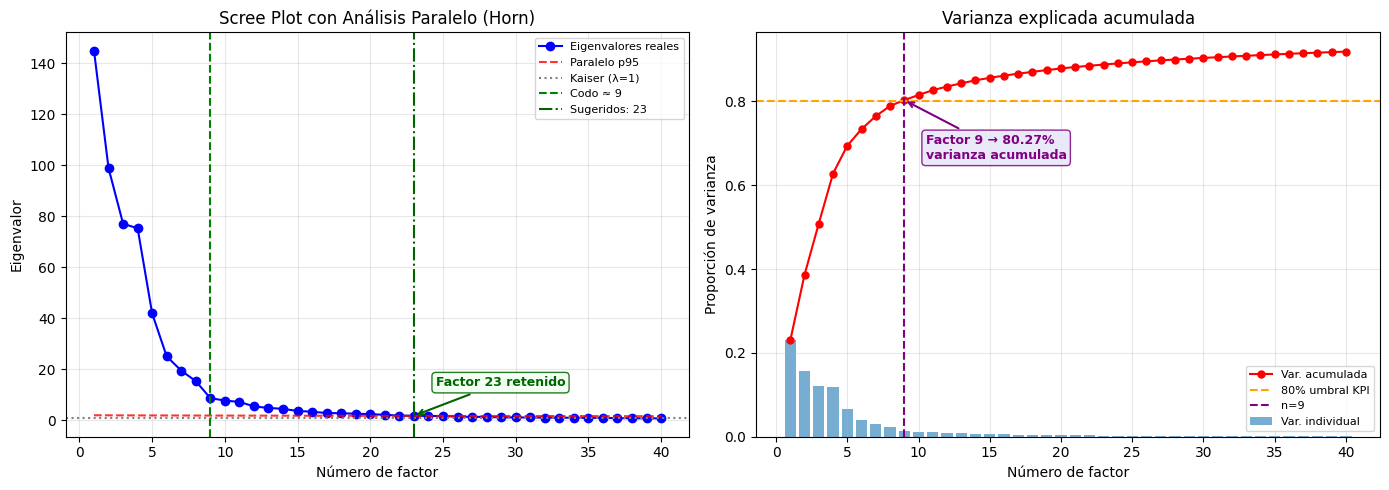

[OK] Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/scree_plot_varianza.png

ANÁLISIS FACTORIAL EXPLORATORIO (9 factores, rotación Varimax)
Rotación aplicada: varimax
Varianza total explicada (Varimax, 9 factores): 62.55%

Matriz de cargas rotadas (primeras 20 dims):
    Factor1  Factor2  Factor3  Factor4  Factor5  Factor6  Factor7  Factor8  Factor9
0    -0.012    0.241    0.715   -0.133   -0.232   -0.166   -0.046   -0.028   -0.040
1     0.057   -0.210    0.829   -0.073   -0.135   -0.094   -0.033   -0.035   -0.037
2     0.002   -0.015    0.008    0.015    0.001    0.116    0.393   -0.020    0.051
3     0.152    0.000   -0.001   -0.010    0.310   -0.043    0.125    0.525   -0.263
4    -0.014    0.004    0.005   -0.008    0.051   -0.009   -0.028    0.527    0.331
5    -0.391    0.510   -0.288    0.514    0.012    0.343   -0.093   -0.063   -0.057
6    -0.183    0.264   -0.104    0.456    0.122    0.662    0.180   -0.040   -0.111
7     0.068    0.537   -0.

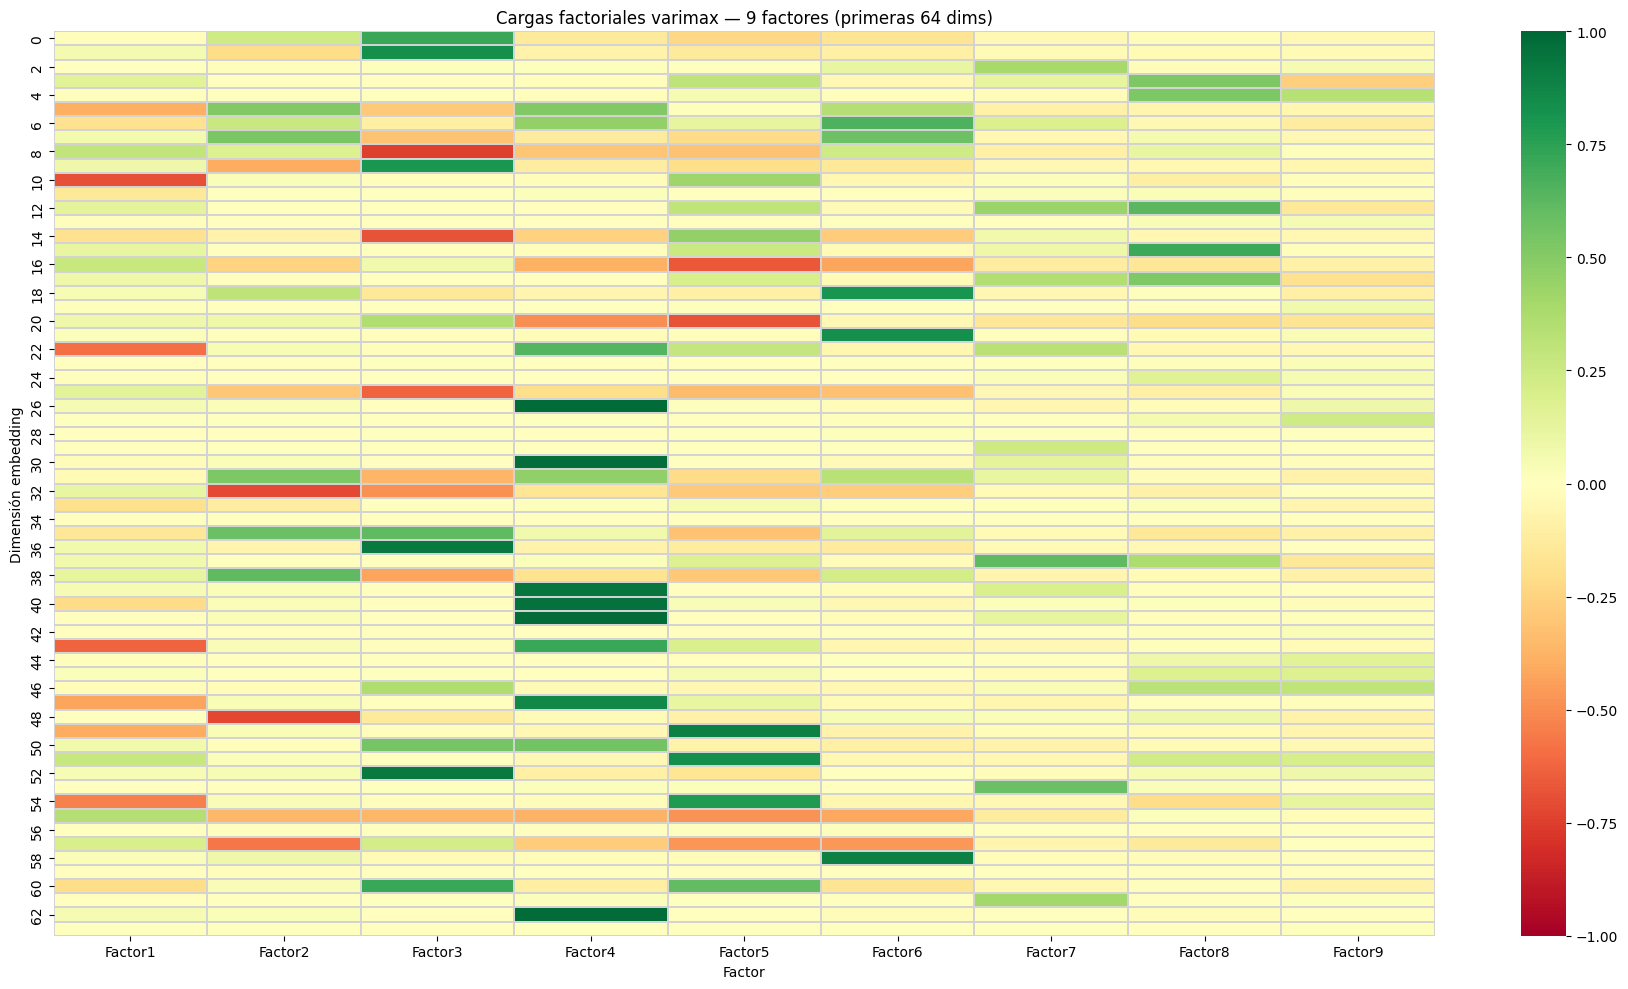

[OK] Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/efa_loadings_heatmap.png

ANÁLISIS FACTORIAL CONFIRMATORIO (CFA) — Modelo de 4 factores

Varianza explicada (4 factores Varimax): 48.90%
  Nota: el EFA exploratorio usa más factores para alcanzar el KPI 80%;
  el CFA testa la estructura teórica de 4 constructos por separado.

  CargaAntropogenica: dims [654, 456, 188, 203, 757]  (|carga máx|=-0.972)
  EstresVegetal: dims [800, 341, 302, 722, 289]  (|carga máx|=0.887)
  DensidadUrbana: dims [482, 254, 742, 612, 377]  (|carga máx|=0.954)
  VolatilidadAtmosferica: dims [687, 576, 246, 123, 194]  (|carga máx|=-0.916)

Modelo CFA:
CargaAntropogenica =~ v654 + v456 + v188 + v203 + v757
EstresVegetal =~ v800 + v341 + v302 + v722 + v289
DensidadUrbana =~ v482 + v254 + v742 + v612 + v377
VolatilidadAtmosferica =~ v687 + v576 + v246 + v123 + v194

Variables observadas: 20 | Muestras: 3344

=== ÍNDICES DE BONDAD DE AJUSTE ===
                       Value
DoF    

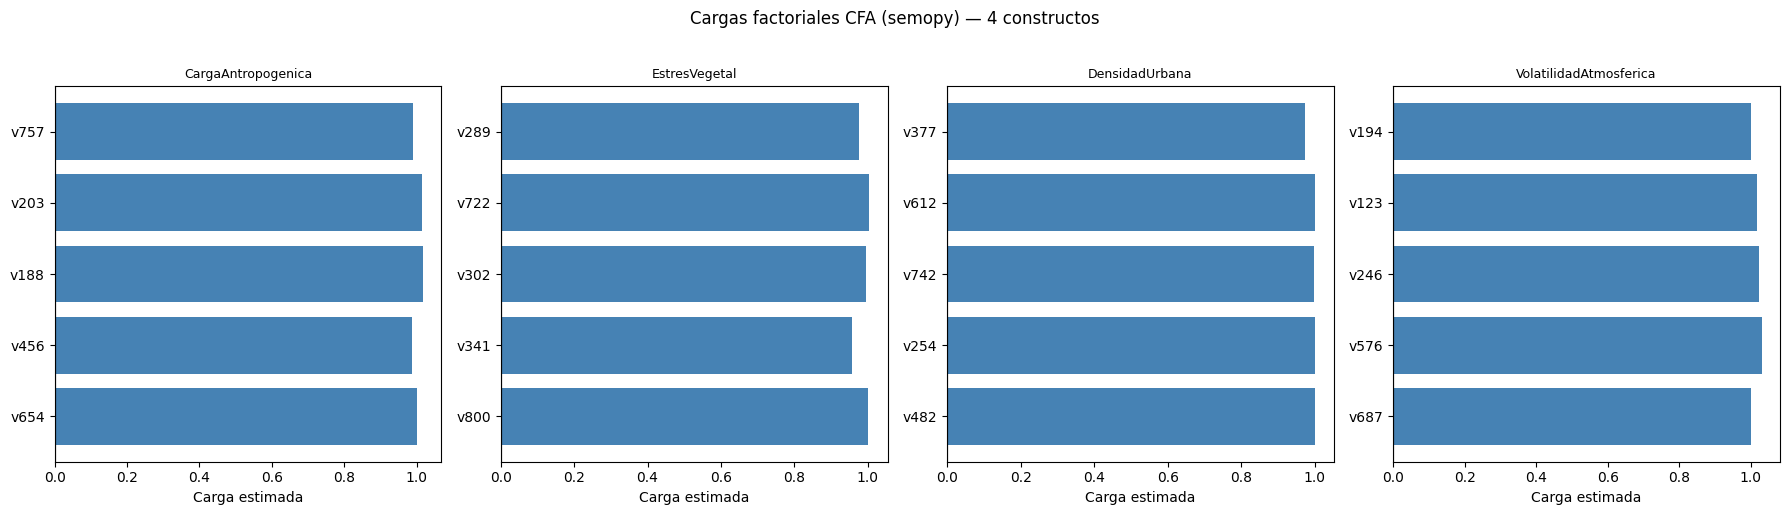

[OK] Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit2/cfa_loadings_barplot.png
[ADVERTENCIA] semplot no disponible: No graphviz module is installed.
  Instalar graphviz para habilitar el diagrama de path.

=== INTERPRETACIÓN ===
Los embeddings contrastivos codifican información espectral y semántica
de alta complejidad. El EFA requiere más factores para explicar ≥80% de
varianza, lo que indica que el espacio latente es más rico que 4 constructos.
El RMSEA=0.176 y CFI=0.902 reflejan que el modelo de 4 factores
es una simplificación del espacio hallado en el AFE. Esto es esperable en
embeddings de aprendizaje contrastivo y no invalida su utilidad.

[OK] Validación psicométrica completada.


In [9]:
# ============================================================================
# 8. EJECUCIÓN COMPLETA
# ============================================================================
BASE = "/teamspace/studios/this_studio/GeoVision-CLIP-Cali/models"

NPZ_PATHS = [
    f"{BASE}/representaciones_geovision_train.npz",  # 2340 muestras
    f"{BASE}/representaciones_geovision_val.npz",    # 502 muestras
    f"{BASE}/representaciones_geovision_test.npz",   # 502 muestras
]

# ── Validación psicométrica AFE + AFC ────────────────────────────────────────
# z_img: activaciones SAE rama visual (3344 × 1024) — lo que pide el PDF (Sit. 2, p.6)
# "Sobre la matriz de embeddings de la rama visual (n × 512), aplicar AFE..."
run_psychometric_validation(npz_paths=NPZ_PATHS, embed_key='z_img')